# LSTM 24 godziny — dobór decyzji i zakłady ±10 USD
Trenujemy wyłącznie jedną konfigurację LSTM: 24 ostatnie zwroty, 16 neuronów, pełna historia.
Zachowujemy dwa seedy i uśrednianie prawdopodobieństw. Trzy rundy oraz końcowy trening oznaczają 8 treningów.

Porównujemy na tych samych predykcjach: próg 0,5, dostrojony próg kierunku oraz próg ze strefą pomijania.
Każda runda ma odrębne okresy: trening → early stopping → dobór decyzji (`tune`) → ocena (`eval`).
Wynik `eval` nie zmienia wybranej reguły. Końcowa reguła jest dopasowywana przed testem i zamrażana.

Trafienie daje +10 USD, pomyłka −10 USD, brak zakładu 0 USD. Klasa 0 obejmuje brak zmiany ceny.
Test był już oglądany, więc jest porównaniem rozwojowym, nie niezależnym potwierdzeniem przewagi.

In [16]:
import time
import ccxt
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, log_loss,
                             roc_auc_score, classification_report, ConfusionMatrixDisplay)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import gc

## Jedna konfiguracja, dwie niezależne decyzje
Próg kierunku `center` przesuwa granicę między spadkiem i wzrostem. `half_width` określa połowę
szerokości strefy pomijania wokół tej granicy. Np. center=0,51 i half_width=0,01:
spadek przy p≤0,50, wzrost przy p≥0,52, pomiędzy nimi brak zakładu.
Przy zerowej szerokości obstawiamy każdą godzinę: p≥center to wzrost, p<center to spadek.
Odległość od przesuniętej granicy jest regułą selekcji, nie skalibrowanym prawdopodobieństwem trafienia.

In [17]:
TICKER = "BTC/USDT"
TIMEFRAME = "1h"
START_DATE = "2023-11-03T20:00:00Z"
END_DATE = "2026-03-31T20:00:00Z"
TEST_START = pd.Timestamp("2025-11-21T11:00:00Z")
COMMON_START = pd.Timestamp("2023-11-14T20:00:00Z")
SEEDS = [42, 123]
MODEL_CONFIG = dict(name="24_returns", lags=24, units=16, features="returns", months=None)
# train_end, stop_end, tune_end, eval_end — wszystkie granice wyłączne, UTC.
FOLD_DATES = [
    ("2025-01-01", "2025-02-01", "2025-03-01", "2025-04-01"),
    ("2025-05-01", "2025-06-01", "2025-07-01", "2025-08-01"),
    ("2025-08-01", "2025-09-01", "2025-10-01", "2025-11-01"),
]
FOLDS = [tuple(pd.Timestamp(x, tz="UTC") for x in dates) for dates in FOLD_DATES]
FINAL_BOUNDS = (pd.Timestamp("2025-09-21T11:00:00Z"),
                pd.Timestamp("2025-10-21T11:00:00Z"), TEST_START,
                pd.Timestamp(END_DATE))
EPOCHS_NUM = 60
BATCH_SIZE = 64
LEARNING_RATE = 0.0003
DROPOUT_RATE = 0.2
PATIENCE_NUM = 8
MIN_DELTA = 0.0001
DIRECTION_THRESHOLDS = [0.47, 0.48, 0.49, 0.50, 0.51, 0.52, 0.53]
SKIP_HALF_WIDTHS = [0.0, 0.005, 0.01, 0.02]
MIN_POLICY_COVERAGE = 0.20
MIN_POLICY_BETS = 100
START_CASH = 1000.0
BET_PAYOUT = 10.0
BOOTSTRAP_REPEATS = 1000
BLOCK_HOURS = 24
CLIENT = ccxt.binance({"enableRateLimit": True})
BAR_MS = int(CLIENT.parse_timeframe(TIMEFRAME) * 1000)
assert all(a < b < c < d <= TEST_START for a,b,c,d in FOLDS)
assert FINAL_BOUNDS[0] < FINAL_BOUNDS[1] < FINAL_BOUNDS[2] < FINAL_BOUNDS[3]
print(f"Plan: {len(FOLDS) * len(SEEDS) + len(SEEDS)} treningów LSTM")

Plan: 8 treningów LSTM


## Dane i cechy wyłącznie z zamkniętych świec
Każdy wskaźnik w wierszu t korzysta najwyżej ze świecy t; sekwencja prognozująca t kończy się na t−1.
Scaler jest dopasowywany od nowa do treningu danej rundy. Nigdy do early stopping, progu ani oceny.

In [18]:
def fetch_data(client, ticker, start_date, end_date, timeframe):
    start_ms = client.parse8601(start_date)
    end_ms = client.parse8601(end_date)
    bar_ms = int(client.parse_timeframe(timeframe) * 1000)
    if start_ms >= end_ms:
        raise ValueError("START_DATE musi poprzedzać END_DATE.")
    cursor, rows = start_ms, []
    while cursor < end_ms:
        for attempt in range(3):
            try:
                batch = client.fetch_ohlcv(ticker, timeframe, since=cursor, limit=1000)
                break
            except ccxt.NetworkError:
                if attempt == 2:
                    raise
                time.sleep(2 ** attempt)
        if not batch:
            break
        next_cursor = max(row[0] for row in batch) + bar_ms
        if next_cursor <= cursor:
            raise RuntimeError("API nie przesuwa zakresu pobierania.")
        rows.extend(batch)
        cursor = next_cursor
    frame = pd.DataFrame(rows, columns=["Date", "Open", "High", "Low", "Close", "Volume"])
    frame = frame.loc[(frame.Date >= start_ms) & (frame.Date < end_ms)
                      & (frame.Date + bar_ms <= client.milliseconds())].copy()
    if frame.empty:
        raise ValueError("Brak zamkniętych świec w podanym zakresie.")
    frame["Date"] = pd.to_datetime(frame.Date, unit="ms", utc=True)
    frame = frame.drop_duplicates("Date").set_index("Date").sort_index()
    expected = pd.date_range(pd.to_datetime(start_ms, unit="ms", utc=True),
                             pd.to_datetime(end_ms, unit="ms", utc=True),
                             freq=pd.Timedelta(milliseconds=bar_ms), inclusive="left")
    missing = expected.difference(frame.index)
    if len(missing):
        raise ValueError(f"Brakuje {len(missing)} świec, np. {missing[:5].tolist()}. Sprawdź zakres/API.")
    if not np.isfinite(frame.to_numpy()).all() or (frame.Close <= 0).any():
        raise ValueError("Dane zawierają niepoprawne wartości.")
    return frame

raw_data = fetch_data(CLIENT, TICKER, START_DATE, END_DATE, TIMEFRAME)
data = raw_data.copy()
data["log_return"] = np.log(data.Close / data.Close.shift(1))
data["return_close"] = data.Close.pct_change(fill_method=None)
FEATURE_SETS = {"returns": ["log_return"]}
data = data.iloc[24:].copy()
if not np.isfinite(data[FEATURE_SETS["returns"] + ["return_close"]].to_numpy()).all():
    raise ValueError("Niepoprawne wartości cech po rozgrzewce.")
data["target"] = (data.return_close > 0).astype("int32")
print(f"Świece: {len(raw_data)}; zakres: {raw_data.index.min()} — {raw_data.index.max()}")
display(pd.DataFrame(FOLDS, columns=["train_end", "stop_end", "tune_end", "eval_end"]))

Świece: 21096; zakres: 2023-11-03 20:00:00+00:00 — 2026-03-31 19:00:00+00:00


,train_end,stop_end,tune_end,eval_end
0,2025-01-01 00:00:00+00:00,2025-02-01 00:00:00+00:00,2025-03-01 00:00:00+00:00,2025-04-01 00:00:00+00:00
1,2025-05-01 00:00:00+00:00,2025-06-01 00:00:00+00:00,2025-07-01 00:00:00+00:00,2025-08-01 00:00:00+00:00
2,2025-08-01 00:00:00+00:00,2025-09-01 00:00:00+00:00,2025-10-01 00:00:00+00:00,2025-11-01 00:00:00+00:00


## Przygotowanie rundy i trening
Wejście zawiera dokładnie 24 godzinowe zwroty poprzedzające etykietę. Scaler jest dopasowany tylko
na treningu rundy. Jeden ensemble dostarcza wspólnych prawdopodobieństw dla wszystkich reguł decyzji.

In [19]:
def prepare_round(frame, config, bounds):
    train_end, stop_end, tune_end, eval_end = bounds
    train_start = max(COMMON_START, train_end - pd.DateOffset(months=config["months"])) if config["months"] else COMMON_START
    columns = FEATURE_SETS[config["features"]]
    fit_mask = (frame.index >= train_start) & (frame.index < train_end)
    if not fit_mask.any():
        raise ValueError("Pusty trening scalera.")
    scaler = StandardScaler().fit(frame.loc[fit_mask, columns])
    positions = np.flatnonzero((frame.index >= train_start) & (frame.index < eval_end))
    if not len(positions) or positions[0] < config["lags"]:
        raise ValueError("Brak historii dla sekwencji.")
    values = scaler.transform(frame[columns]).astype("float32")
    X = np.stack([values[i-config["lags"]:i] for i in positions])
    meta = frame.iloc[positions][["target", "return_close"]].copy()
    meta["previous_return"] = frame.log_return.shift(1).iloc[positions]
    masks = {"train": meta.index < train_end,
             "stop": (meta.index >= train_end) & (meta.index < stop_end),
             "tune": (meta.index >= stop_end) & (meta.index < tune_end),
             "eval": (meta.index >= tune_end) & (meta.index < eval_end)}
    datasets = {}
    for name, mask in masks.items():
        part = meta.loc[mask].copy()
        if part.empty or part.target.nunique() < 2:
            raise ValueError(f"Niepoprawny podzbiór {name}")
        datasets[name] = (X[mask], part.target.to_numpy(dtype="int32"), part)
    return datasets, scaler

def build_model(input_shape, config):
    model = Sequential([Input(shape=input_shape), LSTM(config["units"]),
                        Dropout(DROPOUT_RATE), Dense(1, activation="sigmoid")])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

def fit_ensemble(datasets, config):
    X, y, _ = datasets["train"]
    X_stop, y_stop, _ = datasets["stop"]
    predictions = {name: [] for name in ["tune", "eval"]}
    weights, histories = [], []
    for seed in SEEDS:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(seed)
        model = build_model(X.shape[1:], config)
        history = model.fit(X, y, validation_data=(X_stop, y_stop), epochs=EPOCHS_NUM,
            batch_size=BATCH_SIZE, shuffle=False, verbose=0,
            callbacks=[ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3,
                                        min_delta=MIN_DELTA, min_lr=1e-6),
                       EarlyStopping(monitor="val_loss", patience=PATIENCE_NUM,
                                     min_delta=MIN_DELTA, restore_best_weights=True)])
        print(f"  seed={seed}, epoki={len(history.history['loss'])}, min val_loss={min(history.history['val_loss']):.6f}", flush=True)
        for name in predictions:
            predictions[name].append(model.predict(datasets[name][0], verbose=0).ravel())
        weights.append(model.get_weights())
        histories.append(history.history)
        del model
        gc.collect()
    return {name: np.mean(v, axis=0) for name,v in predictions.items()}, weights, histories

In [20]:
def probability_metrics(y, probability):
    prediction = (np.asarray(probability) >= 0.5).astype(int)
    return {"accuracy": accuracy_score(y, prediction),
            "balanced_accuracy": balanced_accuracy_score(y, prediction),
            "log_loss": log_loss(y, probability, labels=[0, 1]),
            "ROC_AUC": roc_auc_score(y, probability)}

def bet_decisions(probabilities, center, half_width=0.0):
    p = np.asarray(probabilities, dtype=float)
    if p.ndim != 1 or not np.isfinite(p).all() or ((p < 0) | (p > 1)).any():
        raise ValueError("Prawdopodobieństwa muszą być skończonym wektorem w [0, 1].")
    if center is None:
        return np.full(len(p), -1, dtype=int)
    if not np.isfinite(center) or not np.isfinite(half_width) or half_width < 0 or not 0 <= center-half_width <= center+half_width <= 1:
        raise ValueError("Niepoprawna granica lub szerokość strefy pomijania.")
    if half_width == 0:
        return (p >= center).astype(int)
    return np.where(p >= center+half_width, 1, np.where(p <= center-half_width, 0, -1))

def backtest_bets(meta, decisions, start_cash=START_CASH, payout=BET_PAYOUT):
    decisions = np.asarray(decisions, dtype=int)
    if len(decisions) != len(meta) or not np.isin(decisions, [-1, 0, 1]).all():
        raise ValueError("Decyzje muszą mieć długość danych i wartości -1/0/1.")
    if start_cash < 0 or payout <= 0:
        raise ValueError("Niepoprawny kapitał lub wypłata.")
    cash, ledger = float(start_cash), []
    for timestamp, target, decision in zip(meta.index, meta.target.to_numpy(), decisions):
        executed = decision >= 0 and cash >= payout
        pnl = payout * (1 if decision == target else -1) if executed else 0.0
        cash += pnl
        ledger.append({"Date": timestamp, "target": target, "decision": decision,
                       "executed": executed, "pnl_usd": pnl, "cash": cash,
                       "insufficient_cash": decision >= 0 and not executed})
    ledger = pd.DataFrame(ledger).set_index("Date")
    curve = ledger.cash.copy()
    curve.index = curve.index + pd.Timedelta(milliseconds=BAR_MS)
    curve = pd.concat([pd.Series([start_cash], index=[meta.index[0]]), curve])
    bets = int(ledger.executed.sum())
    wins = int((ledger.pnl_usd > 0).sum())
    summary = {"bets": bets, "coverage": bets / len(meta), "wins": wins, "losses": bets-wins,
               "hit_rate": wins/bets if bets else np.nan, "pnl_usd": cash-start_cash,
               "final_cash": cash, "max_drawdown_usd": (curve.cummax()-curve).max(),
               "blocked_by_capital": int(ledger.insufficient_cash.sum())}
    return ledger, curve, summary

def choose_policy(meta, probabilities, allow_skip=True):
    rows = []
    widths = SKIP_HALF_WIDTHS if allow_skip else [0.0]
    for center in DIRECTION_THRESHOLDS:
        for half_width in widths:
            decisions = bet_decisions(probabilities, center, half_width)
            _, _, summary = backtest_bets(meta, decisions)
            rows.append({"center": center, "half_width": half_width,
                         "distance_from_half": abs(center-.5), **summary})
    table = pd.DataFrame(rows)
    table["eligible"] = (table.bets >= MIN_POLICY_BETS) & (table.coverage >= MIN_POLICY_COVERAGE)
    valid = table.loc[table.eligible]
    if allow_skip:
        valid = valid.loc[valid.pnl_usd > 0]  # Brak zakładów ma P&L równy zero.
    if valid.empty:
        policy = {"center": None, "half_width": 0.0}
    else:
        # Remis: większe pokrycie, próg bliżej 0.5, mniejsza szerokość.
        winner = valid.sort_values(["pnl_usd", "coverage", "distance_from_half", "half_width", "center"],
                                  ascending=[False, False, True, True, True]).iloc[0]
        policy = {"center": float(winner.center), "half_width": float(winner.half_width)}
    return policy, table

## Ocena decyzji w trzech rundach
Każdą regułę dopasowujemy wyłącznie na `tune`, a następnie oceniamy na `eval`.
Główna strategia przeszukuje 28 par próg/szerokość i może wybrać brak zakładów.
Wybieramy największy P&L przy minimum 100 zakładach i 20% pokrycia. Przy remisie preferujemy większe
pokrycie i mniejszą zmianę progu. Osobno pokazujemy strojenie samego kierunku bez pomijania — ten wariant
z definicji obstawia wszystkie godziny, także jeśli wynik na `tune` jest ujemny.
Porównanie nie wymaga dodatkowych treningów. Nie wybieramy reguły według wyników `eval` lub testu.

In [21]:
fold_rows, parts, fold_histories = [], [], {}
BEST_CONFIG = MODEL_CONFIG.copy()
BEST_NAME = MODEL_CONFIG["name"]
for fold_id, bounds in enumerate(FOLDS, start=1):
    print(f"LSTM 24 — runda {fold_id}/{len(FOLDS)}", flush=True)
    datasets, _ = prepare_round(data, MODEL_CONFIG, bounds)
    probabilities, _, histories = fit_ensemble(datasets, MODEL_CONFIG)
    tune_meta = datasets["tune"][2]
    direction, _ = choose_policy(tune_meta, probabilities["tune"], allow_skip=False)
    selected, _ = choose_policy(tune_meta, probabilities["tune"], allow_skip=True)
    policies = {"Próg 0.5": {"center": .5, "half_width": 0.0},
                "Dostrojony kierunek": direction, "Próg i pomijanie": selected}
    meta = datasets["eval"][2]
    for name, policy in policies.items():
        decisions = bet_decisions(probabilities["eval"], **policy)
        _, _, summary = backtest_bets(meta, decisions)
        fold_rows.append({"fold": fold_id, "policy": name, **policy, **summary})
    part = meta.copy()
    part["probability"] = probabilities["eval"]
    part["fold"] = fold_id
    parts.append(part)
    fold_histories[fold_id] = histories
fold_table = pd.DataFrame(fold_rows)
display(fold_table)
display(fold_table.groupby("policy").agg(
    mean_pnl=("pnl_usd", "mean"), std_pnl=("pnl_usd", "std"), worst_pnl=("pnl_usd", "min"),
    positive_folds=("pnl_usd", lambda x: int((x>0).sum())), mean_coverage=("coverage", "mean")))
oof_predictions = {BEST_NAME: pd.concat(parts).sort_index()}

LSTM 24 — runda 1/3
  seed=42, epoki=9, min val_loss=0.692337
  seed=123, epoki=12, min val_loss=0.691460
LSTM 24 — runda 2/3
  seed=42, epoki=44, min val_loss=0.686913
  seed=123, epoki=48, min val_loss=0.686560
LSTM 24 — runda 3/3
  seed=42, epoki=14, min val_loss=0.690683
  seed=123, epoki=14, min val_loss=0.690927


,fold,policy,center,half_width,bets,coverage,wins,losses,hit_rate,pnl_usd,final_cash,max_drawdown_usd,blocked_by_capital
0,1,Próg 0.5,0.50,0.0,744,1.0,399,345,0.536290,540.0,1540.0,180.0,0
1,1,Dostrojony kierunek,0.51,0.0,744,1.0,384,360,0.516129,240.0,1240.0,230.0,0
2,1,Próg i pomijanie,0.51,0.0,744,1.0,384,360,0.516129,240.0,1240.0,230.0,0
3,2,Próg 0.5,0.50,0.0,744,1.0,396,348,0.532258,480.0,1480.0,140.0,0
4,2,Dostrojony kierunek,0.47,0.0,744,1.0,399,345,0.536290,540.0,1540.0,140.0,0
5,2,Próg i pomijanie,0.47,0.0,744,1.0,399,345,0.536290,540.0,1540.0,140.0,0
6,3,Próg 0.5,0.50,0.0,744,1.0,381,363,0.512097,180.0,1180.0,170.0,0
7,3,Dostrojony kierunek,0.51,0.0,744,1.0,361,383,0.485215,-220.0,780.0,390.0,0
8,3,Próg i pomijanie,0.51,0.0,744,1.0,361,383,0.485215,-220.0,780.0,390.0,0


,mean_pnl,std_pnl,worst_pnl,positive_folds,mean_coverage
policy,,,,,
Dostrojony kierunek,186.666667,382.796726,-220.0,2,1.0
Próg 0.5,400.000000,192.873015,180.0,3,1.0
Próg i pomijanie,186.666667,382.796726,-220.0,2,1.0


## Diagnostyka prawdopodobieństw przed testem
Przedziały pokazują średnie P(wzrostu), rzeczywistą częstość wzrostów i liczebność. Dodatkowo grupujemy
pewność wybranej klasy i jej trafność. To diagnostyka, nie automatyczne dopasowanie kalibratora na tych samych
wynikach. Jeśli kalibracja będzie potrzebna, powinna dostać osobny wcześniejszy okres.

,count,predicted_up,actual_up
probability_bin,,,
"(0.3, 0.4]",9,0.386840,0.444444
"(0.4, 0.5]",864,0.479784,0.480324
"(0.5, 0.6]",1342,0.524267,0.532042
"(0.6, 0.7]",17,0.615317,0.470588


,count,confidence,hit_rate
confidence_bin,,,
"(0.499, 0.52]",1233,0.509063,0.510949
"(0.52, 0.54]",602,0.528764,0.534884
"(0.54, 0.56]",234,0.548114,0.555556
"(0.56, 0.58]",99,0.569750,0.606061
"(0.58, 0.6]",38,0.588884,0.552632
"(0.6, 0.65]",26,0.614571,0.500000


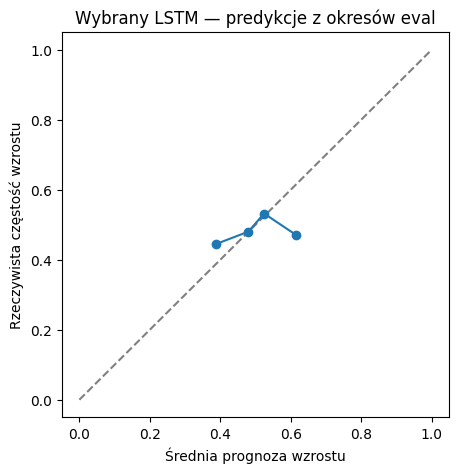

In [22]:
def calibration_tables(frame):
    temp = frame.copy()
    temp["probability_bin"] = pd.cut(temp.probability, np.linspace(0,1,11), include_lowest=True)
    temp["confidence"] = np.maximum(temp.probability, 1-temp.probability)
    temp["correct"] = ((temp.probability >= .5).astype(int) == temp.target)
    temp["confidence_bin"] = pd.cut(temp.confidence, [.5,.52,.54,.56,.58,.60,.65,.75,1.0], include_lowest=True)
    reliability = temp.groupby("probability_bin", observed=True).agg(
        count=("target","size"), predicted_up=("probability","mean"), actual_up=("target","mean"))
    confidence = temp.groupby("confidence_bin", observed=True).agg(
        count=("target","size"), confidence=("confidence","mean"), hit_rate=("correct","mean"))
    return reliability, confidence

reliability, confidence = calibration_tables(oof_predictions[BEST_NAME])
display(reliability)
display(confidence)
plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1], "--", color="gray")
plt.plot(reliability.predicted_up, reliability.actual_up, "o-")
plt.xlabel("Średnia prognoza wzrostu")
plt.ylabel("Rzeczywista częstość wzrostu")
plt.title("Wybrany LSTM — predykcje z okresów eval")
plt.show()

## Końcowy trening LSTM 24 i zamrożenie reguł
Ponownie trenujemy wyłącznie tę samą konfigurację na nowszej historii. Na końcowym `tune` ustalamy
próg kierunku oraz niezależnie parę próg/strefa pomijania. Test nie uczestniczy w wyborze.
Pokazujemy tabelę wszystkich kandydatów, aby rozróżnić poprawę na okresie strojenia od poprawy na teście.

In [23]:
final_data, feature_scaler = prepare_round(data, MODEL_CONFIG, FINAL_BOUNDS)
final_probabilities, final_weights, final_histories = fit_ensemble(final_data, MODEL_CONFIG)
DIRECTION_POLICY, direction_table = choose_policy(final_data["tune"][2], final_probabilities["tune"], allow_skip=False)
SELECTED_POLICY, policy_table = choose_policy(final_data["tune"][2], final_probabilities["tune"], allow_skip=True)
print("Zamrożony próg kierunku:", DIRECTION_POLICY)
print("Zamrożona strategia z opcją pomijania:", SELECTED_POLICY)
display(direction_table)
display(policy_table.sort_values(["eligible", "pnl_usd"], ascending=[False, False]))

  seed=42, epoki=9, min val_loss=0.695096
  seed=123, epoki=9, min val_loss=0.693550
Zamrożony próg kierunku: {'center': 0.5, 'half_width': 0.0}
Zamrożona strategia z opcją pomijania: {'center': 0.5, 'half_width': 0.0}


,center,half_width,distance_from_half,bets,coverage,wins,losses,hit_rate,pnl_usd,final_cash,max_drawdown_usd,blocked_by_capital,eligible
0,0.47,0.0,0.03,744,1.0,370,374,0.497312,-40.0,960.0,240.0,0,True
1,0.48,0.0,0.02,744,1.0,369,375,0.495968,-60.0,940.0,280.0,0,True
2,0.49,0.0,0.01,744,1.0,365,379,0.490591,-140.0,860.0,420.0,0,True
3,0.50,0.0,0.00,744,1.0,390,354,0.524194,360.0,1360.0,150.0,0,True
4,0.51,0.0,0.01,744,1.0,371,373,0.498656,-20.0,980.0,340.0,0,True
5,0.52,0.0,0.02,744,1.0,363,381,0.487903,-180.0,820.0,360.0,0,True
6,0.53,0.0,0.03,744,1.0,376,368,0.505376,80.0,1080.0,250.0,0,True


,center,half_width,distance_from_half,bets,coverage,wins,losses,hit_rate,pnl_usd,final_cash,max_drawdown_usd,blocked_by_capital,eligible
12,0.50,0.000,0.00,744,1.000000,390,354,0.524194,360.0,1360.0,150.0,0,True
23,0.52,0.020,0.02,153,0.205645,87,66,0.568627,210.0,1210.0,70.0,0,True
13,0.50,0.005,0.00,519,0.697581,269,250,0.518304,190.0,1190.0,150.0,0,True
7,0.48,0.020,0.02,599,0.805108,307,292,0.512521,150.0,1150.0,160.0,0,True
10,0.49,0.010,0.01,605,0.813172,310,295,0.512397,150.0,1150.0,180.0,0,True
17,0.51,0.005,0.01,457,0.614247,234,223,0.512035,110.0,1110.0,140.0,0,True
18,0.51,0.010,0.01,245,0.329301,127,118,0.518367,90.0,1090.0,130.0,0,True
24,0.53,0.000,0.03,744,1.000000,376,368,0.505376,80.0,1080.0,250.0,0,True
25,0.53,0.005,0.03,694,0.932796,351,343,0.505764,80.0,1080.0,250.0,0,True
22,0.52,0.010,0.02,505,0.678763,254,251,0.502970,30.0,1030.0,250.0,0,True


## Test — ta sama sieć, trzy sposoby decyzji
Dla strategii pomijającej godziny trafność podajemy wyłącznie wśród wykonanych zakładów w tabeli backtestu.
Log-loss i AUC dotyczą niezmienionych prawdopodobieństw; strojenie progu nie zmienia tych miar.
Pozostają beztreningowe punkty odniesienia: poprzedni kierunek, jego odwrócenie i brak zakładów.

,accuracy,balanced_accuracy,log_loss,ROC_AUC
LSTM próg 0.5,0.511985,0.513204,0.69243,0.535421
LSTM dostrojony kierunek,0.511985,0.513204,0.69243,0.535421
Kontynuacja,0.476190,0.476183,NaN,NaN
Odwrócenie,0.523810,0.523817,NaN,NaN


Raport po dostrojeniu kierunku:
              precision    recall  f1-score   support

           0       0.53      0.22      0.31      1571
           1       0.51      0.81      0.62      1558

    accuracy                           0.51      3129
   macro avg       0.52      0.51      0.47      3129
weighted avg       0.52      0.51      0.47      3129



,bets,coverage,wins,losses,hit_rate,pnl_usd,final_cash,max_drawdown_usd,blocked_by_capital
LSTM wszystkie,3129.0,1.000000,1602.0,1527.0,0.511985,750.0,1750.0,280.0,0.0
LSTM dostrojony kierunek,3129.0,1.000000,1602.0,1527.0,0.511985,750.0,1750.0,280.0,0.0
LSTM wybrana strategia,3129.0,1.000000,1602.0,1527.0,0.511985,750.0,1750.0,280.0,0.0
Odwrócenie,3129.0,1.000000,1639.0,1490.0,0.523810,1490.0,2490.0,230.0,0.0
Kontynuacja,2222.0,0.710131,1061.0,1161.0,0.477498,-1000.0,0.0,1030.0,907.0
Bez zakładów,0.0,0.000000,0.0,0.0,NaN,0.0,1000.0,0.0,0.0


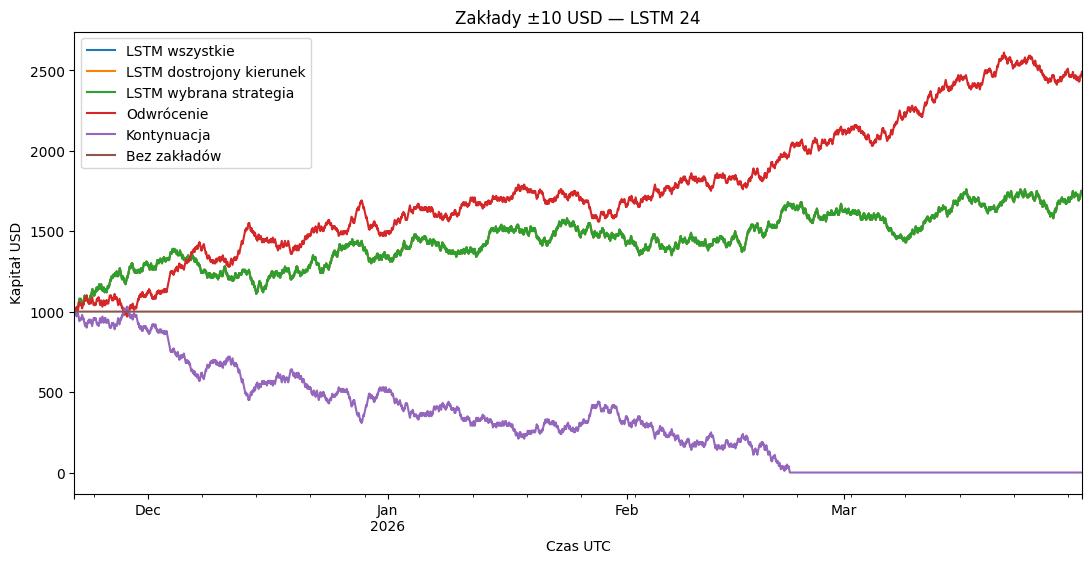

In [24]:
_, y_test, test_meta = final_data["eval"]
test_probabilities = final_probabilities["eval"]
default_predictions = bet_decisions(test_probabilities, .5)
direction_predictions = bet_decisions(test_probabilities, **DIRECTION_POLICY)
classification_rows = {"LSTM próg 0.5": probability_metrics(y_test, test_probabilities)}
if DIRECTION_POLICY["center"] is not None:
    classification_rows["LSTM dostrojony kierunek"] = {
        **probability_metrics(y_test, test_probabilities),
        "accuracy": accuracy_score(y_test, direction_predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test, direction_predictions)}
persistence = (test_meta.previous_return.to_numpy() > 0).astype(int)
for name, prediction in {"Kontynuacja": persistence, "Odwrócenie": 1-persistence}.items():
    classification_rows[name] = {"accuracy": accuracy_score(y_test, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_test, prediction), "log_loss": np.nan, "ROC_AUC": np.nan}
display(pd.DataFrame(classification_rows).T)
if DIRECTION_POLICY["center"] is not None:
    print("Raport po dostrojeniu kierunku:")
    print(classification_report(y_test, direction_predictions, labels=[0,1], zero_division=0))
strategies = {"LSTM wszystkie": default_predictions,
              "LSTM dostrojony kierunek": direction_predictions,
              "LSTM wybrana strategia": bet_decisions(test_probabilities, **SELECTED_POLICY),
              "Odwrócenie": 1-persistence, "Kontynuacja": persistence,
              "Bez zakładów": np.full(len(y_test), -1)}
ledgers, curves, summaries = {}, {}, {}
for name, decisions in strategies.items():
    ledgers[name], curves[name], summaries[name] = backtest_bets(test_meta, decisions)
backtest_table = pd.DataFrame(summaries).T
display(backtest_table)
pd.DataFrame(curves).plot(figsize=(13,6), xlabel="Czas UTC", ylabel="Kapitał USD", title="Zakłady ±10 USD — LSTM 24")
plt.show()
results = test_meta.copy()
results["probability"] = test_probabilities
results["default_prediction"] = default_predictions
results["direction_prediction"] = direction_predictions
results["decision"] = strategies["LSTM wybrana strategia"]

## Stabilność miesięczna i niepewność porównania
Miesięczny P&L sumuje rzeczywiste rozliczenia ciągłej symulacji, bez resetowania kapitału co miesiąc.
Bootstrap blokowy losuje te same 24-godzinne bloki dla obu strategii i porównuje sumy ich potencjalnych
wypłat stałej stawki, bez ograniczenia kapitału. Przerwy w obstawianiu dają zero. Dzięki temu nie porównujemy
różnych zbiorów godzin. Przedział jest przybliżony, zależy od długości bloku i nie uwzględnia wcześniejszego
wielokrotnego oglądania testu. Nie jest gwarancją przyszłej przewagi.

In [25]:
monthly_rows = []
for name, ledger in ledgers.items():
    monthly = ledger.groupby(ledger.index.strftime("%Y-%m")).agg(
        bets=("executed","sum"), pnl_usd=("pnl_usd","sum"),
        wins=("pnl_usd",lambda x:int((x>0).sum())))
    monthly["hit_rate"] = monthly.wins / monthly.bets.replace(0,np.nan)
    monthly["strategy"] = name
    monthly_rows.append(monthly.rename_axis("month").reset_index())
monthly_table = pd.concat(monthly_rows, ignore_index=True)
display(monthly_table.pivot(index="month",columns="strategy",values="pnl_usd"))
display(monthly_table.loc[monthly_table.strategy=="LSTM wybrana strategia"])

def potential_pnl(y, decisions):
    y, decisions = np.asarray(y), np.asarray(decisions)
    return np.where(decisions<0,0.0,np.where(decisions==y,BET_PAYOUT,-BET_PAYOUT))

def paired_block_interval(difference, block_size=BLOCK_HOURS, repeats=BOOTSTRAP_REPEATS, seed=42):
    difference = np.asarray(difference, dtype=float)
    n = len(difference)
    if n < block_size or repeats < 1 or block_size < 1:
        raise ValueError("Niepoprawny rozmiar próby lub bloku.")
    rng = np.random.default_rng(seed)
    totals = np.empty(repeats)
    for i in range(repeats):
        starts = rng.integers(0,n,size=int(np.ceil(n/block_size)))
        indices = ((starts[:,None]+np.arange(block_size))%n).ravel()[:n]
        totals[i] = difference[indices].sum()
    low, high = np.quantile(totals,[.025,.975])
    return {"observed_difference_usd":difference.sum(),"lower_95_usd":low,"upper_95_usd":high}

selected_pnl = potential_pnl(y_test,strategies["LSTM wybrana strategia"])
comparisons = {}
for name in ["Odwrócenie", "LSTM wszystkie", "Bez zakładów"]:
    comparisons[name] = paired_block_interval(selected_pnl-potential_pnl(y_test,strategies[name]))
display(pd.DataFrame(comparisons).T)

strategy,Bez zakładów,Kontynuacja,LSTM dostrojony kierunek,LSTM wszystkie,LSTM wybrana strategia,Odwrócenie
month,,,,,,
2025-11,0.0,-130.0,290.0,290.0,290.0,130.0
2025-12,0.0,-360.0,40.0,40.0,40.0,360.0
2026-01,0.0,-180.0,100.0,100.0,100.0,180.0
2026-02,0.0,-330.0,200.0,200.0,200.0,460.0
2026-03,0.0,0.0,120.0,120.0,120.0,360.0


,month,bets,pnl_usd,wins,hit_rate,strategy
10,2025-11,229,290.0,129,0.563319,LSTM wybrana strategia
11,2025-12,744,40.0,374,0.502688,LSTM wybrana strategia
12,2026-01,744,100.0,377,0.506720,LSTM wybrana strategia
13,2026-02,672,200.0,346,0.514881,LSTM wybrana strategia
14,2026-03,740,120.0,376,0.508108,LSTM wybrana strategia


,observed_difference_usd,lower_95_usd,upper_95_usd
Odwrócenie,-740.0,-1900.5,301.0
LSTM wszystkie,0.0,0.0,0.0
Bez zakładów,750.0,-250.0,1730.0


## Jak ocenić zmianę
- Porównaj trzy reguły na tych samych predykcjach: próg 0.5, dostrojony kierunek i próg ze strefą pomijania.
- Sprawdź średni oraz najgorszy wynik rund. Sama poprawa na `tune` nie dowodzi poprawy poza tym okresem.
- Porównuj trafność razem z liczbą zakładów, P&L i obsunięciem.
- Zmieniamy decyzje, a nie ranking prawdopodobieństw: AUC pozostaje takie samo.
- Porównanie z progiem 0.5 w bootstrapie mierzy efekt nowej reguły przy tej samej sieci.
- Nie dobieraj ustawień ponownie według końcowego testu. Przewagę należy potwierdzić na nowym okresie.

Skaler i wejścia nie korzystają z przyszłych danych. Prognoza t używa dokładnie 24 wcześniejszych świec.
Model nie symuluje cen kontraktów ani opóźnienia wykonania. Rozliczenie pozostaje +10/−10 USD.